# GEOLAB SNIVEL Notebook
@dittmann Aug 2024

Step 1 Station : WGPP Event: ci40865184

    * Process 5Hz from this event
    * Process 1Hz from same event/station
    * pull in 1Hz PPP from same event/station

Step 2: process 5Hz from this event
    * BGIS  EVENT : ci40699207


# Earthquake ci40865184: 
[Shakemap of peak ground motion](https://earthquake.usgs.gov/earthquakes/eventpage/ci40865184/map?shakemap-code=40865184&shakemap-source=ci&shakemap-pgv=true&shakemap-stations=true&shakemap-mmi-contours=false)

![](https://earthquake.usgs.gov/realtime/product/shakemap/40865184/ci/1723090457455/download/intensity.jpg)

2024-08-07 04:09:56 (UTC)

Stations to evaluate using the [radial api](https://api.earthscope.org/beta/docs#get-/discover/gnss/radial):
WGPP

In [111]:
import urllib.request
import json
from datetime import datetime, timedelta
import geopy.distance
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def calculate_p_s_arrival_depth(station, eq):
    
    """
    Function calculates arrival times for P and S waves
    
    Parameters
    ----------
    :param station: gtsm_station class object
        Must include the following attributes
        :station.lat: float
        :station.long: float
    :param eq: earthquake class object
        Must include the following attributes
        :eq.lat: float
        :eq.long: float
        :eq.time: datetime.datetime
    :return:
        Adds attributes to station object
        :station.p_delta: datetime.timedelta 
        :station.s_delta: datetime.timedelta
        :station.p_arrival: datetime.datetime
        :station.s_arrival: datetime.datetime
    """
    
    event_loc="["+str(eq.lat)+","+str(eq.long)+"]"
    station_loc="["+str(station.lat)+","+str(station.long)+"]"
    eq_depth=str(eq.depth)
    url = "https://service.iris.edu/irisws/traveltime/1/query?evloc="+event_loc+"&staloc="+station_loc+"&evdepth="+eq_depth
    df=pd.read_table(url, sep="\s+", header=1, index_col=2, usecols=[2,3])
    
    station.p_delta = timedelta(seconds=float(df.iloc[((df.index == 'P') | (df.index == 'p')).argmax()].Travel))
    station.s_delta = timedelta(seconds=float(df.iloc[((df.index == 'S') | (df.index == 's')).argmax()].Travel))
    station.p_arrival = eq.time + station.p_delta
    station.s_arrival = eq.time + station.s_delta
    return station


class gnss_station:
    """
    Class object containing data and metadata for a gnss station
    """
    
    def __init__(self, fourchar):
        self.name = fourchar

    
class earthquake:
    """
    Class object containing parameters for a specific earthquake event
    """
    
    def __init__(self, eventID):
        self.eventID = eventID

        
def load_event_data(eventID):
    """
    Function loads earthquake parameters for a given event into an earthquake object
       
    Parameters
    ----------
    :param eventID: str
    :return: eq: earthquake class object   
    """
    
    url = "https://earthquake.usgs.gov/fdsnws/event/1/query?format=geojson&eventid="+eventID
    response = urllib.request.urlopen(url)
    data = json.loads(response.read())

    #define earthquake class object
    eq = earthquake(eventID)
    eq.eventID
    eq.name = data["properties"]['title']
    eq.mag = data["properties"]['mag']
    eq.unix_time = data['properties']['time']
    print(eq.unix_time)
    eq.time = datetime.fromtimestamp(eq.unix_time/1000.0)
    eq.time= pd.to_datetime(eq.unix_time, unit='ms')
    print(eq.time)
    eq.lat = data["geometry"]['coordinates'][1]
    eq.long = data["geometry"]['coordinates'][0]
    eq.depth = data["geometry"]['coordinates'][2]
    
    #write_event_coords(eq)
    return eq

def distance(
        ep,
        depth,
        gps):
    """
    distance calculates the hypocentral distances between a station and the epicenter

    Parameters
    ----------
    ep is the lat, long of the event
    depth is the depth of the event (km)
    gps is the lat, long of the station

    :return:
       hypocentral distance in km
    """
    dist =  geopy.distance.geodesic( ep,gps ).km
    hypo = np.sqrt(np.power(dist, 2) + np.power(depth, 2) )
    return hypo

In [150]:
import requests
from pathlib import Path
 
from earthscope_sdk.auth.device_code_flow import DeviceCodeFlowSimple
from earthscope_sdk.auth.auth_flow import NoTokensError

def get_es_file(url, directory_to_save_file='./', token_path='./'):
    """function to get earthscope data using es-sdk
    modified from https://gitlab.com/earthscope/public/earthscope-sdk

    Parameters
    ----------
    url : string
        url of desired file at gage-data.earthscope.org
    directory_to_save_file : str, optional
        path of directory in which to save the file, by default cwd
    token_path : str, optional
        path of directory in which to save the token, by default './'
    """
    # instantiate the device code flow subclass
    device_flow = DeviceCodeFlowSimple(Path(token_path))
    try:
      # get access token from local path
      device_flow.get_access_token_refresh_if_necessary()
    except NoTokensError:
      # if no token was found locally, do the device code flow
      device_flow.do_flow()
    token = device_flow.access_token

    # request a file and provide the token in the Authorization header
    file_name = Path(url).name

    r = requests.get(url, headers={"authorization": f"Bearer {token}"})
    if r.status_code == requests.codes.ok:
      # save the file
      with open(Path(Path(directory_to_save_file) / file_name), 'wb') as f:
          for data in r:
              f.write(data)
    else:
      #problem occured
      print(f"failure: {r.status_code}, {r.reason}")

def read_vel(vfn):
    '''
    array is array from li_df dataframe
    '''
    
    #fname='output/%s/velocities_%s_%03d_%s.txt' %(event,station,doy,year)
    #fname='SNIVEL/output/velocities_%s_%s_%s.txt' %(station,str(doy).zfill(3),year)
    #fpath=os.path.join(os.path.dirname(os.getcwd()), fname)
    vel_df=pd.read_csv(vfn, header=None, sep=' ', usecols=[1,2,3,4,5], names=['gpst','dndt','dedt','dudt','clk'])
    utc_diff=gps_2_utc(vel_df.gpst[0])
    print(utc_diff)
    vel_df['utc'] = vel_df.gpst + utc_diff 
    vel_df.index=(pd.to_datetime(vel_df.utc, unit='s', origin='unix'))
    return vel_df

def gps_2_utc(gpstime):
    '''
    calculates offset between gps time and utc (unix) time
    '''
    # Convert GPS time to UTC and index
    gps = datetime(1980,1,6)
    utc = datetime(1970,1,1)
    diff=gps-utc
    #https://en.racelogic.support/VBOX_Automotive/01General_Information/Knowledge_Base/What_are_GPS_Leap_Seconds%3F
    leap_sec=gpsleapsec(gpstime)
    utc_diff=diff.seconds + diff.days * 86400 - leap_sec #total seconds including leap seconds
    return utc_diff
    #CREATE FUNCTION FOR LEAP SECONDS

def gpsleapsec(gpssec):
    '''
    number of leapseconds at given gps time epoch
    taken from B.Crowell's Snivel package
    '''
    leaptimes = np.array([46828800, 78364801, 109900802, 173059203, 252028804, 315187205, 346723206, 393984007, 425520008, 457056009, 504489610, 551750411, 599184012, 820108813, 914803214, 1025136015, 1119744016, 1167264017])
    leapseconds = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18])
    a1 = np.where(gpssec > leaptimes)[0]
    leapsec = len(a1)
    return(leapsec)

def utc_time(dt):
    epoch = datetime.utcfromtimestamp(0)
    return timedelta(seconds=dt*1e-3) + epoch

def plot_vel(dst,eq, site, hypod):
    #from obspy.signal.filter import lowpass
    colors=['#e41a1c','#377eb8','#4daf4a','#984ea3','#ff7f00']
    
    #for site in MyList[:4]:
        #site='p158'
    
    vfn=dst
    vel_df=read_vel(vfn)
    vel_df=vel_df[abs(vel_df.dudt)<1]
    
    fig, ax = plt.subplots(3, 1, figsize=(8,6), sharex=True)
    
    for i,direc in enumerate(['dndt','dedt','dudt']):
        ax[i].plot((vel_df.index-eq.time).total_seconds(),vel_df[direc])
        #ax[i].plot((vel_df.index-eq.time).total_seconds(), lowpass(vel_df[direc], freq=1, df=5, corners=4, zerophase=True), label='Low-pass', color=colors[4])
    
        #plt.axvline(pd.to_datetime('2021-11-09 06:25:17'))
        ax[i].axvline((eq.time-eq.time).total_seconds(), color='black')
        ax[i].axvline((station.s_arrival-eq.time).total_seconds(), color='red')
        ax[i].axvline((station.p_arrival-eq.time).total_seconds(), color='green')
        ax[i].set_ylabel('%s (m/s)' %direc)
        #ax[i].set_ylim([-.1,.1])
    #hypo_radius=sta_used[sta_used.stations==site].HypocentralDistance.values[0]
    ax[0].set_title('%s \n %02dkm from %s' %(site, hypod, eq.name))
    #ax[i].set_xlim([eq.time-datetime.timedelta(minutes=0.5), station.s_arrival+datetime.timedelta(minutes=.5)])
    ax[i].set_xlim([-10,40])
    plt.show()

## GET PPP DATA

#stream_id='GEOSNCL%s.CI.LY_.20' %site.upper()
#url='https://api.earthscope.org/beta/data-products/gnss/positions/instantaneous?stream_id=%s&start_datetime=%s&end_datetime=%s' %(stream_id, start_date.isoformat(), end_date.isoformat())
#hard coded for now
def get_es_ppp(site, token_path='./'):
    
    #hardcoded date for now into url
    # my iso datetime 2024-08-07T04:09:26.760000
    # what the API wants? 2024-08-07T04%3A09%3A26%2B00%3A00
    
    url='https://api.earthscope.org/beta/data-products/gnss/positions/instantaneous?stream_id=GEOSNCL%3A'+site.upper()+'.CI.LY_.20&start_datetime=2024-08-07T04%3A09%3A26%2B00%3A00&end_datetime=2024-08-07T04%3A14%3A26%2B00%3A00'
    import requests
    from pathlib import Path
     
    from earthscope_sdk.auth.device_code_flow import DeviceCodeFlowSimple
    from earthscope_sdk.auth.auth_flow import NoTokensError
    
    #url = "https://data.unavco.org/path/to/data_file"
    # example: "https://data.unavco.org/archive/gnss/rinex/obs/2022/298/ar272980.22d.Z"
    
    # instantiate the device code flow subclass
    device_flow = DeviceCodeFlowSimple(Path(token_path))
    try:
        # get access token from local path
        device_flow.get_access_token_refresh_if_necessary()
    except NoTokensError:
        # if no token was found locally, do the device code flow
        device_flow.do_flow()
    token = device_flow.access_token
     
    # request a file and provide the token in the Authorization header
    file_name = Path(url).name
    directory_to_save_file = Path.cwd() # where you want to save the downloaded file 
    
    r = requests.get(url, headers={"authorization": f"Bearer {token}", "accept-encoding": "gzip"})
    
    j = r.json()
    
    df = pd.DataFrame.from_dict(j)
    #hardcode in gps to UTC
    df['time']=df.time-18e3
    df['utc'] = df['time'].map(lambda a: utc_time(a))
    df=df.set_index('utc')
    return df
    
def plot_ppp(df,eq, site, hypod):
    #from obspy.signal.filter import lowpass
    colors=['#e41a1c','#377eb8','#4daf4a','#984ea3','#ff7f00']
    
    #for site in MyList[:4]:
        #site='p158'
    
    
    fig, ax = plt.subplots(3, 1, figsize=(8,6), sharex=True)
    
    for i,direc in enumerate(['north','east','up']):
        ax[i].plot((df.index-eq.time).total_seconds(),df[direc])
        #ax[i].plot((vel_df.index-eq.time).total_seconds(), lowpass(vel_df[direc], freq=1, df=5, corners=4, zerophase=True), label='Low-pass', color=colors[4])
    
        #plt.axvline(pd.to_datetime('2021-11-09 06:25:17'))
        ax[i].axvline((eq.time-eq.time).total_seconds(), color='black')
        ax[i].axvline((station.s_arrival-eq.time).total_seconds(), color='red')
        ax[i].axvline((station.p_arrival-eq.time).total_seconds(), color='green')
        ax[i].set_ylabel('%s (m)' %direc)
        #ax[i].set_ylim([-.5,.5])
    #hypo_radius=sta_used[sta_used.stations==site].HypocentralDistance.values[0]
    ax[0].set_title('%s \n %02dkm from %s' %(site, hypod, eq.name))
    #ax[i].set_xlim([eq.time-datetime.timedelta(minutes=0.5), station.s_arrival+datetime.timedelta(minutes=.5)])
    ax[i].set_xlim([-10,40])
    plt.show()

# establish event and site/station objects

In [26]:
eventID='ci40865184'
eq=load_event_data(eventID)
epicenter = (eq.lat, eq.long)

#TODO pull this from the radial aPI
# TODO add radius from Magnitude/sensitivyt relationship
site='wgpp'

station = gnss_station(site)

#TODO pull this from the API instead
station.lat=35.0108493 
station.long=-118.98369274

station=calculate_p_s_arrival_depth(station, eq)

hypod=distance(  epicenter , eq.depth, (station.lat,station.long))

#start_date=datetime.fromisoformat('2024-08-07 04:09:56')
start_date=(eq.time-timedelta(seconds=30)).to_pydatetime()
duration=60*5#seconds
end_date=start_date+timedelta(seconds=duration)


1723003796760
2024-08-07 04:09:56.760000


## Snivel CONFIG

In [5]:
# STATIONS FILE
# TODO, have this generated from radial API
MyList = ['wgpp']
MyFile=open('sites_process.txt','w')

for element in MyList:
     MyFile.write(element)
     MyFile.write('\n')
MyFile.close()

In [6]:
# DATES FILE
eq_doy=(eq.time-datetime(eq.time.year, 1, 1)).days + 1
eq_year=eq.time.year

#dates file
t_string=(pd.to_datetime(eq.time)-timedelta(minutes=0.5)).strftime('%X')
t_string=(pd.to_datetime(eq.time)-timedelta(minutes=1)).strftime('%X')
duration=2
#2019 187 03:19:00 5
text_file = open("dates_process.txt", "w")
n = text_file.write('%s %s %s %s' %(eq_year,str(eq_doy).zfill(3),t_string,duration))
text_file.close()

## SNIVEL PROCESS

Currently a user can swap `rate` to process / store 1 hz or 5hz.

Not very robust with file naming, etc.. but a start.

In [54]:
# Get Earthscope 5Hz/1Hz data 
# (this should be wrapped into SNIVEL eventually)
# eventually need to differentiate between 1hz/5hz...
rate=1

import string
alpha_list=list(string.ascii_lowercase)
eq_hod_alpha=alpha_list[eq.time.hour]
#https://gage-data.earthscope.org/archive/gnss/highrate/5-Hz/rinex/2024
url='https://gage-data.earthscope.org/archive/gnss/rinex/obs/%s/%s/%s%s0.%sd.Z' %(eq_year, str(eq_doy).zfill(3), site, str(eq_doy).zfill(3),eq_year-2000)
# I want to try to only get the hourly file
file_alpha='%s%s%s.%sd.Z' %(site, str(eq_doy).zfill(3),eq_hod_alpha, eq_year-2000)
# otherwise go for generic all file
file_gen='%s%s0.%sd.Z' %(site, str(eq_doy).zfill(3), eq_year-2000)
if rate==5:
    file_n=file_alpha
if rate==1:
    file_n=file_gen
url='https://gage-data.earthscope.org/archive/gnss/highrate/%s-Hz/rinex/%s/%s/%s/' %(rate,eq_year,eq_doy,site)+ file_n 
directory_to_save_file='rinex_hr/rinex_%shz/' %rate
get_es_file(url, directory_to_save_file=directory_to_save_file)

# move 5hz into ../rinex
import shutil
shutil.copyfile(directory_to_save_file+file_n, 'rinex_hr/'+file_gen)

In [56]:
#snivel_mp ==multiprocessing module used if multiple stations in sites_process file
!python SNIVEL_mp.py

#move results to sample rate directories 
vfn='velocities_%s_%s_%s.txt' %(site,str(eq_doy).zfill(3),eq_year)
src='output/'+vfn
dst='output/output_%shz/' %rate + vfn
shutil.copyfile(src, dst)

Navigation file nav/brdc2200.24n already exists
There are 4 CPUs on this machine 
Processing station  wgpp  on year and  day  2024 220
/home/jovyan/SNIVEL/SNIVEL_mp.py:218: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  dran0 = math.sqrt(math.pow(dxsat0[int(asv)],2)+math.pow(dysat0[int(asv)],2)+math.pow(dzsat0[int(asv)],2))
/home/jovyan/SNIVEL/SNIVEL_mp.py:221: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  l1diff = l11[j]-l10[int(asv)]-dran
/home/jovyan/SNIVEL/SNIVEL_mp.py:222: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array be

'output/output_1hz/velocities_wgpp_220_2024.txt'

315964782


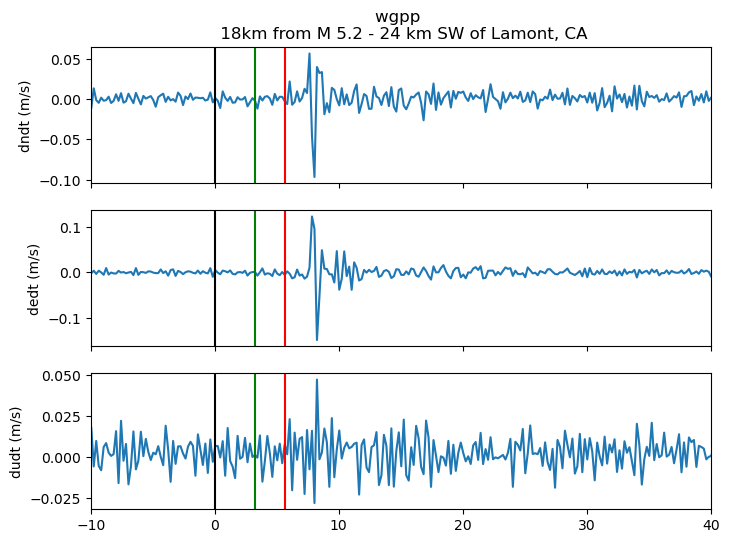

315964782


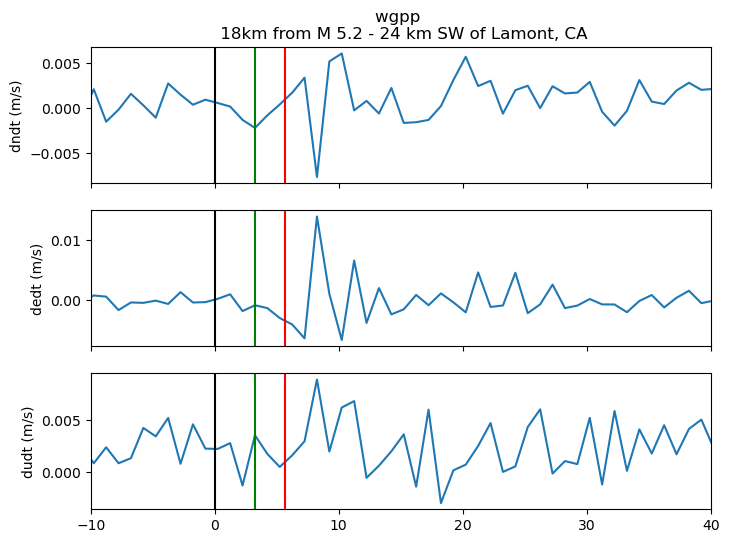

In [151]:
plot_vel('output/output_5hz/velocities_wgpp_220_2024.txt',eq, site, hypod)
plot_vel('output/output_1hz/velocities_wgpp_220_2024.txt',eq, site, hypod)

In [142]:
df=get_es_ppp(site)

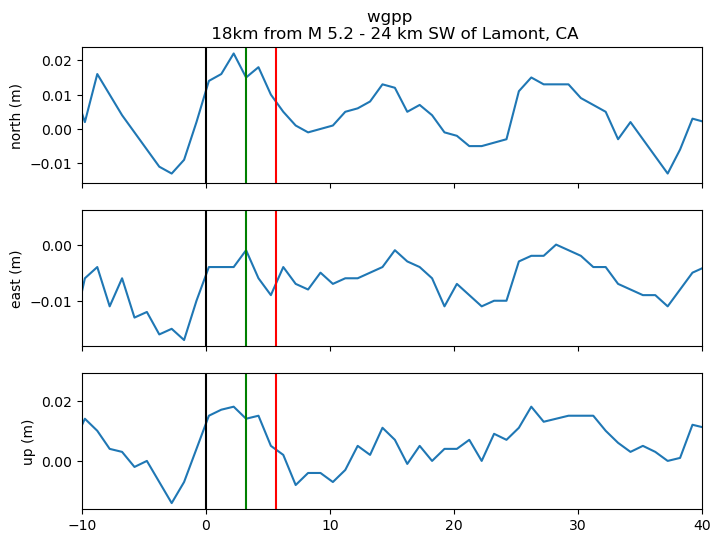

In [146]:
plot_ppp(df,eq, site, hypod)

In [152]:
# TODO compare with 1hz TDCPGO in s3? 

In [147]:
# TODO: modify ALEX's WIZARDRY

In [ ]:
import asyncio
import datetime
import json

import httpx
import pandas as pd
import polars as pl


async def get(
    client: httpx.AsyncClient,
    stream_id: str,
    start: datetime.datetime,
    end: datetime.datetime,
):
    resp = await client.get(
        "/positions/stream_data",
        params={
            "stream_id": stream_id,
            "start_datetime": start.isoformat(),
            "end_datetime": end.isoformat(),
            "format": "arrow-ipc",
            # "format": "parquet",
            # "format": "csv",
            # "format": "json-series",
            # "format": "json-records",
            # "format": "geojson",
        },
        headers={"accept-encoding": "gzip"},
    )

    buf = await resp.aread()
    print(resp.num_bytes_downloaded)
    # print(resp)
    try:
        return pl.read_ipc(buf)
        # return pl.read_parquet(buf)
        # return pl.read_csv(buf)
        # return pl.from_dict(json.loads(buf))
        # return pl.from_dicts(json.loads(buf))
        return pl.from_dicts(json.loads(buf)["data"])
    except Exception as e:
        # print(e)
        return None


async def main():
    period = datetime.timedelta(hours=24)

    async with httpx.AsyncClient(
        # base_url="http://localhost:8000",
        base_url="https://j99gix04qa-vpce-0650da07436322db2.execute-api.us-east-2.amazonaws.com/dev",
        verify=False,
        timeout=httpx.Timeout(300.0),
    ) as client:

        futs = [
            get(client, "GEOSNCL:P548.CI.LY_.20", d, d + period)
            for d in pd.date_range(
                datetime.datetime(2024, 5, 1), periods=60, freq=period
            )
            .to_pydatetime()
            .tolist()
        ]

        s = datetime.datetime.now()
        print(f"{s}: starting")
        dfs = await asyncio.gather(*futs)
        print(f"{datetime.datetime.now() - s}: got all results")

        combined = pl.concat([d for d in dfs if d is not None])
        combined = combined.sort(by="time")

        print(combined)


asyncio.run(main())